In [1]:
import sys
sys.path.insert(0, '../')

from src.load_data import PatientLoader
from src.process import NeuroFeatureExtractor

## Import Data

In [2]:
from nilearn import plotting, image, masking
import numpy as np
import matplotlib.pyplot as plt

In [3]:
file_path = "data/original/sub-2004"
loader = PatientLoader()
recording = loader.load(file_path)

### Correlation Matrix --> a partir de atlas

In [4]:
extractor = NeuroFeatureExtractor(target_resolution=3)

[fetch_atlas_harvard_oxford] Dataset found in /root/nilearn_data/fsl

In [7]:
time_series = extractor.extract_time_series(recording)

/app/src/process.py:45: UserWarning: Casting data from int16 to float32
  time_series = self.masker.fit_transform(recording.func.img)


In [9]:
connectivity_matrix = extractor.extract_functional_connectivity(time_series)

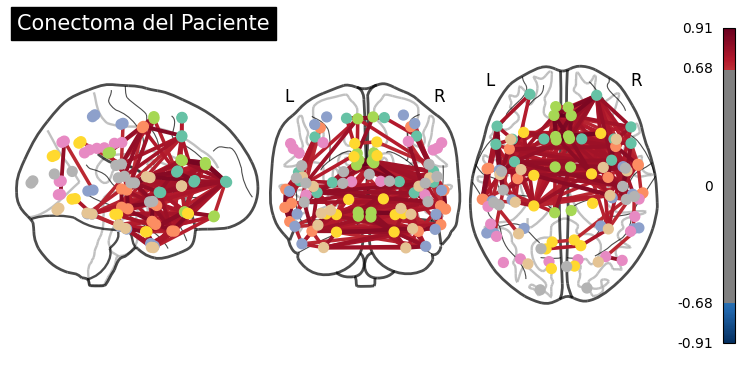

In [11]:
atlas_filename = extractor.atlas.maps
extracted_labels = extractor.masker.labels_

all_coords = plotting.find_parcellation_cut_coords(atlas_filename)

# Now plot
plotting.plot_connectome(
    adjacency_matrix=connectivity_matrix,
    node_coords=all_coords,
    edge_threshold='95%',
    title="Conectoma del Paciente"
)
